<a href="https://colab.research.google.com/github/Malicef/Sistemas-Inteligentes/blob/main/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5° Projeto  Rede MLP para Detecção de Intrusão

Disciplina: PAM0466– SISTEMAS INTELIGENTES

Docente: Pedro Thiago Valerio de Souza

Discentes: Maria Alice Ferreira Teixeira e Thiago Luan Moreira Sousa

## Objetivo

Este projeto tem como objetivo implementar uma rede Perceptron Multicamadas (MLP) utilizando PyTorch para classificar conexões de rede como normais ou ataques, utilizando o dataset NSL-KDD.

O problema é tratado como classificação binária:
- 0 → conexão normal;
- 1 → ataque.

Ao longo do trabalho serão realizados:
- carregamento e preparação dos dados;
- codificação de atributos categóricos;
- normalização dos atributos;
- construção da arquitetura MLP;
- treinamento e validação;
- avaliação final utilizando métricas de classificação.

# Importação das Bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para:
- manipulação dos dados;
- pré-processamento;
- construção da rede neural;
- treinamento da MLP;
- cálculo das métricas;
- visualização gráfica dos resultados.

In [1]:
import kagglehub
import torch
import os
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Download do Dataset

O dataset NSL-KDD é obtido a partir do Kaggle utilizando a biblioteca `kagglehub`.

Os arquivos:
- KDDTrain+.txt
- KDDTest+.txt

serão utilizados como conjuntos de treino e teste.

In [2]:
path = kagglehub.dataset_download("hassan06/nslkdd")

train_path = os.path.join(path, "KDDTrain+.txt")
test_path = os.path.join(path, "KDDTest+.txt")

Using Colab cache for faster access to the 'nslkdd' dataset.


# Definição das Colunas

Nesta etapa são definidos os nomes das colunas do dataset NSL-KDD conforme especificado na documentação do projeto.

O conjunto possui atributos:
- numéricos;
- categóricos;
- rótulo da classe;
- nível de dificuldade.

In [3]:
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "attack_type", "difficulty_level"
]

# Carregamento dos Dados

Os arquivos de treino e teste são carregados utilizando a biblioteca pandas.

Cada registro representa uma conexão de rede contendo atributos relacionados ao comportamento do tráfego.

In [4]:
train = pd.read_csv(
    train_path,
    names=col_names
)

test = pd.read_csv(
    test_path,
    names=col_names
)

train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


# Remoção da Coluna de Dificuldade

A coluna `difficulty_level` foi removida por não fazer parte do problema de classificação proposto.

In [5]:
train.drop("difficulty_level", axis=1, inplace=True)
test.drop("difficulty_level", axis=1, inplace=True)

# Binarização dos Rótulos

O problema foi transformado em classificação binária:
- normal → 0
- ataque → 1

In [6]:
train["attack_type"] = train["attack_type"].apply(lambda x: 0 if x == "normal" else 1)
test["attack_type"] = test["attack_type"].apply(lambda x: 0 if x == "normal" else 1)

# One-Hot Encoding

Os atributos categóricos:
- protocol_type
- service
- flag

foram convertidos utilizando One-Hot Encoding para permitir processamento pela rede neural.

In [7]:
categorical_columns = ["protocol_type", "service", "flag"]

train = pd.get_dummies(train, columns=categorical_columns)
test = pd.get_dummies(test, columns=categorical_columns)

# Alinhamento dos Conjuntos

Os conjuntos de treino e teste foram alinhados para garantir que ambos possuam exatamente as mesmas colunas após o One-Hot Encoding.

In [8]:
train, test = train.align(test, join="left", axis=1, fill_value=0)

In [9]:
X_train = train.drop(columns=['attack_type'])
y_train = train['attack_type']

X_test = test.drop(columns=['attack_type'])
y_test = test['attack_type']

# Normalização dos Dados

Os atributos numéricos foram normalizados utilizando padronização Z-score.

A normalização é necessária para garantir estabilidade durante o treinamento da rede neural.

A padronização é definida por:

$$
z = \frac{x - \mu}{\sigma}
$$

onde:
- $\mu$ representa a média;
- $\sigma$ representa o desvio padrão.

As estatísticas de normalização foram calculadas apenas sobre o conjunto de treino, evitando vazamento de informação.

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)
y_train = torch.tensor(y_train, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

In [12]:
dataset = TensorDataset(X_train, y_train)
dataloader = DataLoader(dataset, batch_size=256, shuffle=False)

# Construção da Rede MLP

A rede MLP foi implementada utilizando PyTorch por meio da classe `nn.Module`.

A arquitetura escolhida possui:
- camada de entrada;
- duas camadas ocultas com ativação ReLU;
- camada de saída com um neurônio.

A função de ativação da saída não foi aplicada manualmente, pois será utilizada internamente pela função `BCEWithLogitsLoss`.

In [13]:
class MLP(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

# Inicialização do Modelo

Nesta etapa são definidos:
- o modelo MLP;
- o otimizador Adam;
- a função de perda BCEWithLogitsLoss.

In [14]:
input_size = X_train.shape[1]
model = MLP(input_size)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

# Separação de Validação

20% do conjunto de treino foi reservado para validação.

O conjunto de validação será utilizado para monitorar a capacidade de generalização do modelo durante o treinamento.

In [15]:
val_size = int(0.2 * len(X_train))
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

In [16]:
train_ds = TensorDataset(X_tr, y_tr)
train_dl = DataLoader(train_ds, batch_size=256, shuffle=False)

In [17]:
train_losses, val_losses = [], []
best_val_loss = float('inf')
patience, patience_counter = 10, 0

# Treinamento da Rede

A rede MLP foi treinada durante até 50 épocas utilizando mini-batches de tamanho 256.

Durante o treinamento foram registradas:
- a loss de treino;
- a loss de validação.

A função de perda utilizada foi a Binary Cross Entropy com logits (`BCEWithLogitsLoss`), apropriada para problemas de classificação binária.

Também foi utilizada a estratégia de Early Stopping, interrompendo o treinamento quando a loss de validação deixa de apresentar melhora, evitando overfitting.

In [18]:
for epoch in range(50):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_dl:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(X_batch)
    train_losses.append(epoch_loss / len(X_tr))

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val)
        val_loss = criterion(val_preds, y_val).item()
    val_losses.append(val_loss)
    print(f"Época {epoch+1:02d} | Loss Treino: {train_losses[-1]:.4f} | Loss Val: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping na época {epoch+1}.")
            break

Época 01 | Loss Treino: 0.0893 | Loss Val: 0.0364
Época 02 | Loss Treino: 0.0296 | Loss Val: 0.0278
Época 03 | Loss Treino: 0.0213 | Loss Val: 0.0230
Época 04 | Loss Treino: 0.0182 | Loss Val: 0.0210
Época 05 | Loss Treino: 0.0167 | Loss Val: 0.0186
Época 06 | Loss Treino: 0.0154 | Loss Val: 0.0170
Época 07 | Loss Treino: 0.0145 | Loss Val: 0.0173
Época 08 | Loss Treino: 0.0139 | Loss Val: 0.0162
Época 09 | Loss Treino: 0.0132 | Loss Val: 0.0164
Época 10 | Loss Treino: 0.0129 | Loss Val: 0.0160
Época 11 | Loss Treino: 0.0123 | Loss Val: 0.0149
Época 12 | Loss Treino: 0.0118 | Loss Val: 0.0161
Época 13 | Loss Treino: 0.0117 | Loss Val: 0.0149
Época 14 | Loss Treino: 0.0116 | Loss Val: 0.0155
Época 15 | Loss Treino: 0.0108 | Loss Val: 0.0165
Época 16 | Loss Treino: 0.0106 | Loss Val: 0.0147
Época 17 | Loss Treino: 0.0102 | Loss Val: 0.0150
Época 18 | Loss Treino: 0.0098 | Loss Val: 0.0146
Época 19 | Loss Treino: 0.0114 | Loss Val: 0.0222
Época 20 | Loss Treino: 0.0110 | Loss Val: 0.0149


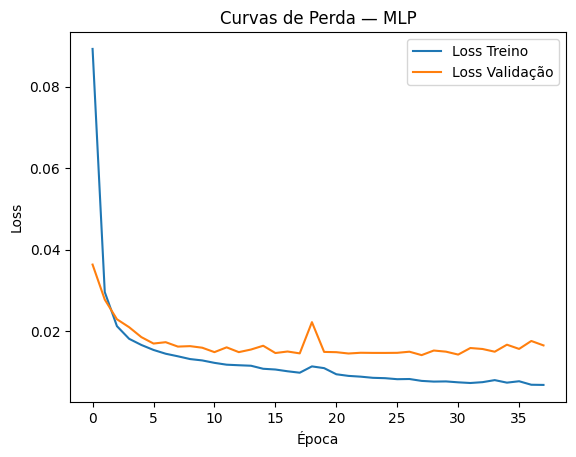

In [19]:
plt.plot(train_losses, label='Loss Treino')
plt.plot(val_losses, label='Loss Validação')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Curvas de Perda — MLP')
plt.legend()
plt.show()

## Análise das Curvas de Loss

As curvas de loss mostram comportamento consistente durante o treinamento da rede MLP.

Observa-se uma redução acentuada da loss nas primeiras épocas, indicando aprendizado rápido dos padrões presentes nos dados.

Após as primeiras épocas, as curvas passam a apresentar estabilização gradual, mantendo valores baixos de loss tanto no conjunto de treino quanto no conjunto de validação.

A proximidade entre as curvas sugere boa capacidade de generalização da rede, sem evidências significativas de overfitting.

Além disso, o mecanismo de Early Stopping interrompeu automaticamente o treinamento na época 38, evitando treinamento desnecessário após a estabilização da loss de validação.

# Avaliação Final

Após o treinamento, o melhor modelo salvo durante a validação foi carregado para avaliação final no conjunto de teste.

In [20]:
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

with torch.no_grad():
    logits = model(X_test)
    probs = torch.sigmoid(logits).numpy()

In [21]:
y_pred = (probs >= 0.5).astype(int).flatten()
y_true = y_test.numpy().flatten().astype(int)

Acurácia:  0.7996
Precisão:  0.9258
Recall:    0.7044
F1-Score:  0.8001


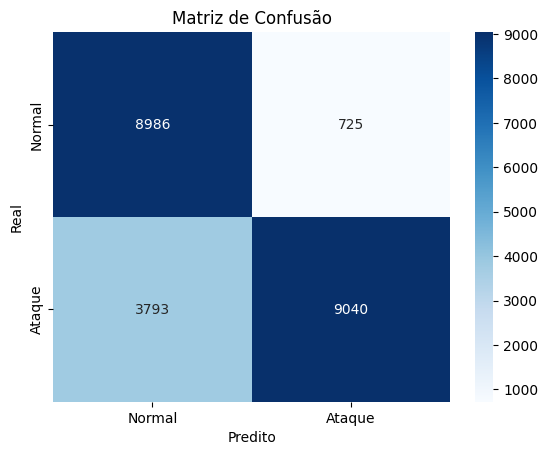

In [22]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print(f"Acurácia:  {acc:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Ataque'],
            yticklabels=['Normal','Ataque'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

## Análise das Métricas

Os resultados obtidos demonstram que a rede MLP apresentou excelente desempenho na tarefa de detecção de intrusão.

A acurácia de aproximadamente 79,96% indica boa capacidade geral de classificação das conexões de rede.

A precisão de aproximadamente 92,58% mostra que a maioria das conexões classificadas como ataque realmente correspondem a ataques reais.

O recall de aproximadamente 70,44% indica que parte dos ataques ainda não foi identificada pela rede, gerando falsos negativos.

O F1-Score de aproximadamente 80,02% demonstra equilíbrio satisfatório entre precisão e recall.

A matriz de confusão mostra que:
- 8996 conexões normais foram classificadas corretamente;
- 9040 ataques foram identificados corretamente;
- 3793 ataques foram classificados incorretamente como normais;
- 725 conexões normais foram classificadas incorretamente como ataques.

Esses resultados indicam que o modelo priorizou maior precisão na identificação de ataques, reduzindo falsos positivos, embora ainda existam falsos negativos relevantes.

# Discussão Sobre os Erros de Classificação

Em sistemas reais de detecção de intrusão, o erro mais crítico é o Falso Negativo.

Esse erro ocorre quando um ataque é classificado incorretamente como uma conexão normal.

No contexto de segurança computacional, falsos negativos são especialmente perigosos, pois permitem que ataques reais passem despercebidos pelo sistema de monitoramento, podendo comprometer dados, serviços e infraestrutura crítica.

Na matriz de confusão obtida, observa-se a presença de falsos negativos, representados pelos ataques classificados como conexões normais.

Já os falsos positivos, embora indesejáveis, normalmente resultam apenas em alertas incorretos ou verificações adicionais de segurança.

Por esse motivo, em aplicações reais de cibersegurança costuma-se priorizar modelos com maior recall, buscando reduzir ao máximo a quantidade de ataques não detectados.

# Conclusão

A rede MLP mostrou-se adequada para o problema de detecção de intrusão utilizando o dataset NSL-KDD.

A utilização de múltiplas camadas ocultas e funções de ativação não lineares permitiu modelar padrões complexos presentes nos dados de rede.

Os resultados obtidos demonstraram boa capacidade de generalização, estabilidade durante o treinamento e desempenho satisfatório na identificação de ataques.

O uso da normalização Z-score contribuiu para maior estabilidade numérica durante o treinamento, enquanto o otimizador Adam e a função BCEWithLogitsLoss proporcionaram aprendizado eficiente da rede.

Além disso, a estratégia de Early Stopping ajudou a evitar overfitting, interrompendo automaticamente o treinamento após estabilização da loss de validação.

Apesar dos bons resultados, a presença de falsos negativos indica que ainda existem ataques não detectados pela rede, o que pode representar risco em aplicações reais de segurança computacional.

Como trabalhos futuros, poderiam ser exploradas arquiteturas mais profundas, técnicas de balanceamento de classes ou ajustes de hiperparâmetros para melhorar ainda mais o recall do modelo.